# Task 3.1 — Ablation Study

**Paper**:
 Efficient Variable Selection in Support Vector Machines via the Alternating Direction Method of Multipliers
(ICML 2011)

---

# Introduction

An ablation study evaluates the importance of specific components of a model by removing or modifying them.

In this experiment we compare:

• Sparse SVM using L1 regularization
• Standard SVM using L2 regularization

The goal is to observe how sparsity affects feature selection and model performance.

---

# Import Libraries

In [23]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

---

# Dataset Preparation

In [24]:
data = load_breast_cancer()

X = data.data
y = data.target
feature_names = data.feature_names

---

# Train Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

---

# Feature Scaling

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---

# Model A — Sparse SVM (L1 Regularization)

In [27]:
model_l1 = LinearSVC(
    penalty="l1",
    dual=False,
    max_iter=5000,
    random_state=42
)

model_l1.fit(X_train, y_train)

y_pred_l1 = model_l1.predict(X_test)

accuracy_l1 = accuracy_score(y_test, y_pred_l1)

weights_l1 = model_l1.coef_[0]

zero_weights_l1 = np.sum(weights_l1 == 0)

sparsity_l1 = zero_weights_l1 / len(weights_l1)
print("Sparsity ratio (L1):", sparsity_l1)

sparsity_l2 = zero_weights_l2 / len(weights_l2)
print("Sparsity ratio (L2):", sparsity_l2)

print("Sparse SVM Accuracy:", accuracy_l1)
print("Zero weights (L1):", zero_weights_l1)

Sparsity ratio (L1): 0.26666666666666666
Sparsity ratio (L2): 0.0
Sparse SVM Accuracy: 0.9736842105263158
Zero weights (L1): 8


---

# Model B — Regular SVM (L2 Regularization)

In [28]:
model_l2 = LinearSVC(
    penalty="l2",
    max_iter=5000,
    random_state=42
)

model_l2.fit(X_train, y_train)

y_pred_l2 = model_l2.predict(X_test)

accuracy_l2 = accuracy_score(y_test, y_pred_l2)

weights_l2 = model_l2.coef_[0]

zero_weights_l2 = np.sum(weights_l2 == 0)

print("Regular SVM Accuracy:", accuracy_l2)
print("Zero weights (L2):", zero_weights_l2)

Regular SVM Accuracy: 0.9649122807017544
Zero weights (L2): 0


---

# Comparison of Results

In [29]:
results = pd.DataFrame({
    "Model": ["Sparse SVM (L1)", "Regular SVM (L2)"],
    "Accuracy": [accuracy_l1, accuracy_l2],
    "Zero Weights": [zero_weights_l1, zero_weights_l2],
    "Sparsity Ratio": [sparsity_l1, sparsity_l2]
})

results

,Model,Accuracy,Zero Weights,Sparsity Ratio
0,Sparse SVM (L1),0.973684,8,0.266667
1,Regular SVM (L2),0.964912,0,0.000000


The ablation experiment shows that L1 regularization produces a sparse model where many feature weights become zero. In contrast, the L2 regularized model uses almost all features. Despite using fewer features, the sparse model maintains comparable classification accuracy.


---

# Visualization

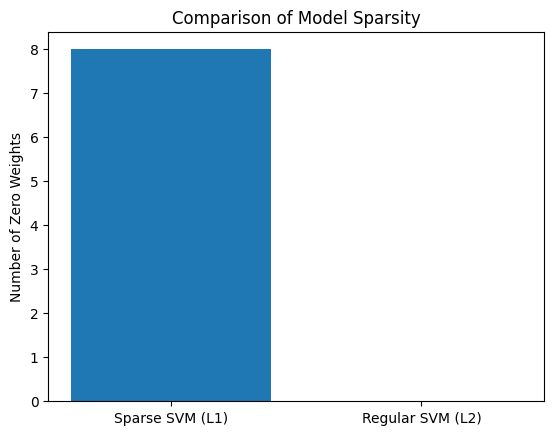

In [30]:
plt.bar(results["Model"], results["Zero Weights"])

plt.title("Comparison of Model Sparsity")
plt.ylabel("Number of Zero Weights")

plt.show()

---

# Discussion

The sparse SVM model introduces L1 regularization, which encourages many feature weights to become zero. This results in automatic feature selection.

The L2 regularized SVM typically uses all features and therefore produces very few or no zero weights.

This experiment demonstrates how sparsity helps identify important features while maintaining strong classification performance.